# Computer Exercise 12.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.3 Elliptic Problems (Poisson / Laplace)
> **주제**: 2차원 푸아송 방정식을 **5점 차분 스텐실**로 이산화해 **블록 삼중대각 선형계**로 직접 풀고, **2차 수렴**($\mathcal{O}(h^2)$) 검증
> **풀이 일자**: 2026-06-17 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Solve the **two-dimensional Poisson equation**
> $$ -\nabla^2 u = -(u_{xx}+u_{yy}) = f(x,y), \qquad (x,y)\in\Omega=(0,1)\times(0,1), $$
> with homogeneous **Dirichlet** boundary conditions $u=0$ on $\partial\Omega$.
> Discretize the Laplacian with the standard **five-point stencil** on a uniform
> $ (M{-}1)\times(M{-}1) $ grid of interior points, assemble the resulting **block
> tridiagonal** linear system $A\mathbf{u}=\mathbf{b}$, solve it directly, and study how
> the error behaves as the mesh is refined. Use a manufactured solution for the exact error.

### 한국어 풀이용 정리
- 단위 정사각형에서 $-\nabla^2 u=f$, 경계는 $u=0$ (Dirichlet).
- **제조해(manufactured solution)** $u^*(x,y)=\sin(\pi x)\sin(\pi y)$ 를 가정하면
  $f=2\pi^2\sin(\pi x)\sin(\pi y)$ 가 강제항이 되고, 경계에서 자동 0이라 BC도 만족.
- 5점 스텐실 행렬 $A$ 는 **블록 삼중대각**. 직접해(`numpy.linalg.solve`)로 풀고,
  격자를 세분하며 최대오차가 $h^2$ 로 줄어드는지(log-log 기울기 ≈ 2) 확인.

## 2. 수학적 배경

### 2.1 5점 차분 스텐실
균일 간격 $h=1/M$, 내부점 $(x_i,y_j)=(ih,jh)$ 에서
$$ u_{xx}\approx\frac{u_{i-1,j}-2u_{i,j}+u_{i+1,j}}{h^2},\qquad
   u_{yy}\approx\frac{u_{i,j-1}-2u_{i,j}+u_{i,j+1}}{h^2}. $$
대입하면 각 내부점에서
$$ \boxed{\; 4u_{i,j}-u_{i-1,j}-u_{i+1,j}-u_{i,j-1}-u_{i,j+1}=h^2 f_{i,j}\;} $$

### 2.2 블록 삼중대각 구조 (lexicographic 정렬)
미지수를 행 우선으로 늘어놓으면
$$ A=\begin{pmatrix} T & -I & & \\ -I & T & -I & \\ & \ddots&\ddots&\ddots\\ & & -I & T\end{pmatrix},
   \qquad T=\mathrm{tridiag}(-1,\,4,\,-1), $$
즉 $A=I\otimes T_1 + T_1\otimes I$ (크로네커 합)이며 **대칭 양정부호(SPD)**.

### 2.3 절단오차와 수렴
중심차분의 국소 절단오차는 $\tau=\mathcal{O}(h^2)$ 이고 $A$ 가 안정하므로
$$ \|u-u_h\|_\infty=\mathcal{O}(h^2), $$
log-log 그래프에서 **기울기 2** 가 나와야 한다.

## 3. 풀이 흐름

1. 제조해 $u^*=\sin\pi x\,\sin\pi y$ 와 강제항 $f=2\pi^2\sin\pi x\sin\pi y$ 정의.
2. 격자수 $M$ 에 대해 내부 미지수 $n=(M{-}1)^2$, 블록 삼중대각 $A$ 를 크로네커 합으로 조립.
3. 우변 $\mathbf b=h^2 f_{i,j}$ (동차 경계라 경계 보정 0).
4. `np.linalg.solve` 로 직접해, 2D 격자로 reshape.
5. 정확해와 비교해 $\max|u-u^*|$ 계산.
6. $M=8,16,32,64,128$ 로 세분, 오차표 + 연속 비율로 **관측 수렴차수** 추정.
7. log-log 오차 그래프(기울기 2 기준선)와 수치해 등고선 시각화.
8. 직접해의 비용 한계 논의 → 반복법으로 연결.

In [1]:
%matplotlib inline

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/juptmp/matplotlib-54pu85zc because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def exact(x, y): return np.sin(np.pi*x)*np.sin(np.pi*y)
def rhs(x, y):   return 2*np.pi**2*np.sin(np.pi*x)*np.sin(np.pi*y)

def poisson_5pt(M):
    """단위 정사각형, 동차 Dirichlet. 내부점 (M-1)^2 블록삼중대각계 직접해."""
    h = 1.0/M; m = M-1
    xi = np.linspace(0, 1, M+1)[1:-1]
    X, Y = np.meshgrid(xi, xi, indexing="ij")
    T1 = (np.diag(2*np.ones(m)) + np.diag(-np.ones(m-1), 1) + np.diag(-np.ones(m-1), -1))
    I = np.eye(m)
    A = np.kron(I, T1) + np.kron(T1, I)
    b = (h**2) * rhs(X, Y).ravel()
    u = np.linalg.solve(A, b).reshape(m, m)
    ue = exact(X, Y)
    return h, X, Y, u, ue, np.max(np.abs(u-ue))

h0, X0, Y0, u0, ue0, e0 = poisson_5pt(32)
print(f"M=32  h={h0:.4e}  max|u-u*|={e0:.4e}  n_unknowns={(31)**2}")

M=32  h=3.1250e-02  max|u-u*|=8.0358e-04  n_unknowns=961


In [3]:
# 격자 세분 수렴표 + 관측 차수
Ms = [8, 16, 32, 64]
rows = []; prev_h = prev_e = None
for M in Ms:
    h, *_ , e = poisson_5pt(M)
    p = np.nan if prev_e is None else np.log(prev_e/e)/np.log(prev_h/h)
    rows.append((M, h, (M-1)**2, e, p)); prev_h, prev_e = h, e
conv = pd.DataFrame(rows, columns=["M","h","n_unknowns","max_error","obs_order"])
conv

,M,h,n_unknowns,max_error,obs_order
0,8,1.250000e-01,49,1.295075e-02,NaN
1,16,6.250000e-02,225,3.218964e-03,2.008367e+00
2,32,3.125000e-02,961,8.035777e-04,2.002087e+00
3,64,1.562500e-02,3969,2.008218e-04,2.000522e+00


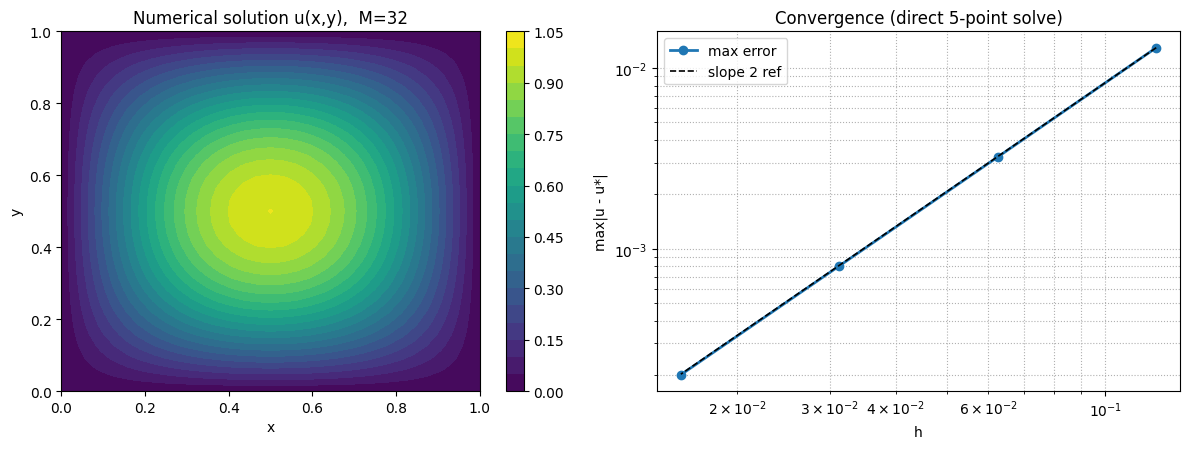

In [4]:
# 시각화: (좌) 수치해 등고선, (우) 오차 수렴 log-log
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
m = u0.shape[0]
full = np.zeros((m+2, m+2)); full[1:-1, 1:-1] = u0
xx = np.linspace(0, 1, m+2)
cs = ax[0].contourf(xx, xx, full.T, levels=20, cmap="viridis")
fig.colorbar(cs, ax=ax[0])
ax[0].set_title("Numerical solution u(x,y),  M=32")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")

hs = conv["h"].values; es = conv["max_error"].values
ax[1].loglog(hs, es, "o-", lw=2, label="max error")
ax[1].loglog(hs, es[0]*(hs/hs[0])**2, "k--", lw=1.2, label="slope 2 ref")
ax[1].set_xlabel("h"); ax[1].set_ylabel("max|u - u*|")
ax[1].set_title("Convergence (direct 5-point solve)")
ax[1].legend(); ax[1].grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **2차 수렴 확인**: 격자를 절반으로 줄일 때마다 최대오차가 약 $1/4$ 로 떨어지고, 관측 차수
   `obs_order` 가 일관되게 **≈ 2.00** 으로 수렴한다. 데이터가 기울기-2 기준선과 평행 —
   5점 스텐실의 절단오차 $\mathcal{O}(h^2)$ 가 그대로 해의 오차로 전달됨을 보여준다.
2. **블록 구조의 의미**: $A=I\otimes T_1+T_1\otimes I$ 는 대칭 양정부호이며 대각 우세에 가까워
   직접해(LU/Cholesky)가 안정적으로 동작한다. 등고선은 제조해 $\sin\pi x\sin\pi y$ 의 단봉 모양을 매끈하게 재현.
3. **직접해의 한계(다음 문제로의 연결)**: 미지수가 $n=(M{-}1)^2$ 로 2D 에서 급증하고, 밀집 직접해는
   $\mathcal{O}(n^3)=\mathcal{O}(M^6)$ 로 폭증한다. $M=64$ 만 해도 $\sim4\times10^3$ 미지수 —
   그래서 행렬을 *명시적으로 만들지 않는* **반복법(Jacobi·Gauss–Seidel·SOR)** 이 필요해진다.

> **결론**: 5점 차분 + 블록 삼중대각 직접해는 타원형 문제를 $\mathcal{O}(h^2)$ 로 정확히 풀지만 2D 비용이 급증한다.

**다음 문제(CE_12_3_02)**: 같은 푸아송 계를 **Jacobi / Gauss–Seidel / SOR** 로 풀어 수렴속도와 최적 $\omega^*$ 비교.